## 0. Setup

In [49]:
%load_ext autoreload
%autoreload 2
import sys
sys.path.insert(0, "..")
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option("display.max_columns", 40)
os.makedirs("figures/eda_05_01", exist_ok=True)
os.makedirs("./data/processed", exist_ok=True)
%matplotlib inline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1. Rebuild Analytical Dataset

Rather than re-downloading from Azure, read the processed parquet files saved by EDA 02 and EDA 03, then re-run the spatial join and temporal filter. This keeps the EDA self-contained and fast.

In [50]:
from datetime import datetime, timezone
from src.geo import find_nearby_stations
from src.features import (
    merge_on_station, filter_within_time_window
)

# Load from processed parquets where available, else re-fetch
import os
stations_reference_path = "./data/processed/stations_reference.parquet"
road_path  = "./data/processed/road_closures_clean.parquet"
train_station_day_path = "./data/processed/train_station_day.parquet"

if os.path.exists(road_path) and os.path.exists(train_station_day_path):
    road_df  = pd.read_parquet(road_path)
    train_station_day = pd.read_parquet(train_station_day_path)
    stations_ref_df = pd.read_parquet(stations_reference_path)
    print(f"Loaded from parquet: {len(road_df):,} closures, {len(train_station_day):,} station - train moments, {len(stations_ref_df):,} stations")
else:
    print("Processed parquets not found - run EDA 01 and EDA 02 first.")
    raise FileNotFoundError("Missing processed parquets")

Loaded from parquet: 352 closures, 5,300 station - train moments, 2,594 stations


In [58]:
# Spatial join
expanded_road_df = find_nearby_stations(road_df, stations_ref_df, min_km=10, max_km=25)
print(f"Closure-station pairs: {len(expanded_road_df):,}")
display(expanded_road_df.head())

Closure-station pairs: 20,384


,closure_id,closure_type,closure_start_time,closure_end_time,start_hour,start_dow,start_date,duration_hours,effective_duration_hours,effective_end_time,effective_start_time,validity_status,cause_type,station_name,station_code,stanox,tpl,distance_in_km
0,481398,planned,2026-04-11 19:00:00,2026-04-12 05:00:00,19,5,2026-04-11,10.0,10.0,2026-04-12 05:00:00,2026-04-11 19:00:00,planned,roadMaintenance,Dullingham,DUL,47006,DULNGHM,21.561992
1,481398,planned,2026-04-11 19:00:00,2026-04-12 05:00:00,19,5,2026-04-11,10.0,10.0,2026-04-12 05:00:00,2026-04-11 19:00:00,planned,roadMaintenance,Ely,ELY,46273,ELYY,21.974512
2,481398,planned,2026-04-11 19:00:00,2026-04-12 05:00:00,19,5,2026-04-11,10.0,10.0,2026-04-12 05:00:00,2026-04-11 19:00:00,planned,roadMaintenance,Foxton,FXN,47242,FOXTON,13.545760
3,481398,planned,2026-04-11 19:00:00,2026-04-12 05:00:00,19,5,2026-04-11,10.0,10.0,2026-04-12 05:00:00,2026-04-11 19:00:00,planned,roadMaintenance,Great Chesterford,GRC,47311,GTCHSFD,22.207451
4,481398,planned,2026-04-11 19:00:00,2026-04-12 05:00:00,19,5,2026-04-11,10.0,10.0,2026-04-12 05:00:00,2026-04-11 19:00:00,planned,roadMaintenance,Huntingdon,HUN,45201,HNTNGDN,19.527520


## 2: Expand road closures into active days

In [59]:
road_station_day = expanded_road_df.copy()

road_station_day["effective_start_time"] = pd.to_datetime(
    road_station_day["effective_start_time"],
    utc=True,
    errors="coerce"
)

road_station_day["effective_end_time"] = pd.to_datetime(
    road_station_day["effective_end_time"],
    utc=True,
    errors="coerce"
)

road_station_day = road_station_day.dropna(
    subset=["effective_start_time", "effective_end_time", "station_name"]
).copy()

road_station_day["planned_date"] = road_station_day.apply(
    lambda row: pd.date_range(
        row["effective_start_time"].floor("D"),
        row["effective_end_time"].floor("D"),
        freq="D"
    ),
    axis=1
)

road_station_day = road_station_day.explode("planned_date").copy()
road_station_day["planned_date"] = pd.to_datetime(
    road_station_day["planned_date"]
).dt.date

display(road_station_day.head())
print(f"Road station-day rows: {len(road_station_day):,}")

,closure_id,closure_type,closure_start_time,closure_end_time,start_hour,start_dow,start_date,duration_hours,effective_duration_hours,effective_end_time,effective_start_time,validity_status,cause_type,station_name,station_code,stanox,tpl,distance_in_km,planned_date
0,481398,planned,2026-04-11 19:00:00,2026-04-12 05:00:00,19,5,2026-04-11,10.0,10.0,2026-04-12 05:00:00+00:00,2026-04-11 19:00:00+00:00,planned,roadMaintenance,Dullingham,DUL,47006,DULNGHM,21.561992,2026-04-11
0,481398,planned,2026-04-11 19:00:00,2026-04-12 05:00:00,19,5,2026-04-11,10.0,10.0,2026-04-12 05:00:00+00:00,2026-04-11 19:00:00+00:00,planned,roadMaintenance,Dullingham,DUL,47006,DULNGHM,21.561992,2026-04-12
1,481398,planned,2026-04-11 19:00:00,2026-04-12 05:00:00,19,5,2026-04-11,10.0,10.0,2026-04-12 05:00:00+00:00,2026-04-11 19:00:00+00:00,planned,roadMaintenance,Ely,ELY,46273,ELYY,21.974512,2026-04-11
1,481398,planned,2026-04-11 19:00:00,2026-04-12 05:00:00,19,5,2026-04-11,10.0,10.0,2026-04-12 05:00:00+00:00,2026-04-11 19:00:00+00:00,planned,roadMaintenance,Ely,ELY,46273,ELYY,21.974512,2026-04-12
2,481398,planned,2026-04-11 19:00:00,2026-04-12 05:00:00,19,5,2026-04-11,10.0,10.0,2026-04-12 05:00:00+00:00,2026-04-11 19:00:00+00:00,planned,roadMaintenance,Foxton,FXN,47242,FOXTON,13.545760,2026-04-11


Road station-day rows: 30,782


## 3: Aggregate road closures to station-day level

In [60]:
road_station_day_agg = (
    road_station_day
    .groupby(["station_name", "stanox", "planned_date"], dropna=False)
    .agg(
        road_closure_count=("closure_id", "nunique"),
        min_distance_km=("distance_in_km", "min"),
        mean_distance_km=("distance_in_km", "mean"),
        max_effective_duration_hours=("effective_duration_hours", "max"),
        mean_effective_duration_hours=("effective_duration_hours", "mean"),
        # Inverse-distance-weighted closure intensity: closer closures count more
        inv_distance_sum=("distance_in_km", lambda x: (1 / x).sum()),
    )
    .reset_index()
)

# Count unplanned closures separately (planned vs unplanned have different disruption profiles)
n_unplanned = (
    road_station_day[road_station_day["closure_type"] == "unplanned"]
    .groupby(["station_name", "stanox", "planned_date"])["closure_id"]
    .nunique()
    .reset_index(name="n_unplanned_closures")
)
road_station_day_agg = road_station_day_agg.merge(
    n_unplanned, on=["station_name", "stanox", "planned_date"], how="left"
)
road_station_day_agg["n_unplanned_closures"] = (
    road_station_day_agg["n_unplanned_closures"].fillna(0).astype(int)
)

road_station_day_agg["has_road_closure"] = (
    road_station_day_agg["road_closure_count"] > 0
).astype(int)

## 4: Merge train and road station-day datasets

In [61]:
display(train_station_day.head())

,station_name,stanox,planned_date,train_movements,mean_delay_minutes,median_delay_minutes,late_movements,mean_late_minutes,median_late_minutes,max_late_minutes,early_movements,mean_early_minutes,median_early_minutes,max_early_minutes,delayed_movements_5min,severe_delay_movements_15min,late_share,early_share,delayed_share_5min,severe_delay_share_15min
0,Abbey Wood,88601,2026-04-10,15,0.566667,-0.50,5,1.133333,0.0,12.0,9,0.566667,0.50,1.5,1,0,0.333333,0.6,0.066667,0.0
1,Abbey Wood,88601,2026-04-11,2,-0.750000,-0.75,0,0.000000,0.0,0.0,2,0.750000,0.75,1.0,0,0,0.000000,1.0,0.000000,0.0
2,Abbey Wood,88601,2026-04-12,3,1.500000,0.50,3,1.500000,0.5,3.5,0,0.000000,0.00,0.0,0,0,1.000000,0.0,0.000000,0.0
3,Aber,78371,2026-04-10,4,2.625000,2.00,2,3.125000,2.5,7.5,2,0.500000,0.50,1.0,1,0,0.500000,0.5,0.250000,0.0
4,Aber,78371,2026-04-11,2,-0.500000,-0.50,0,0.000000,0.0,0.0,2,0.500000,0.50,0.5,0,0,0.000000,1.0,0.000000,0.0


In [62]:
station_day_df = train_station_day.merge(
    road_station_day_agg,
    on=["station_name", "stanox", "planned_date"],
    how="left"
)

road_cols = [
    "road_closure_count",
    "n_unplanned_closures",
    "min_distance_km",
    "mean_distance_km",
    "max_effective_duration_hours",
    "mean_effective_duration_hours",
    "inv_distance_sum",
    "has_road_closure",
]

for col in road_cols:
    if col in station_day_df.columns:
        station_day_df[col] = station_day_df[col].fillna(0)

display(station_day_df.head())
print(station_day_df.shape)

,station_name,stanox,planned_date,train_movements,mean_delay_minutes,median_delay_minutes,late_movements,mean_late_minutes,median_late_minutes,max_late_minutes,early_movements,mean_early_minutes,median_early_minutes,max_early_minutes,delayed_movements_5min,severe_delay_movements_15min,late_share,early_share,delayed_share_5min,severe_delay_share_15min,road_closure_count,min_distance_km,mean_distance_km,max_effective_duration_hours,mean_effective_duration_hours,inv_distance_sum,n_unplanned_closures,has_road_closure
0,Abbey Wood,88601,2026-04-10,15,0.566667,-0.50,5,1.133333,0.0,12.0,9,0.566667,0.50,1.5,1,0,0.333333,0.6,0.066667,0.0,7.0,10.191189,18.115876,6.5,2.357143,0.414091,4.0,1.0
1,Abbey Wood,88601,2026-04-11,2,-0.750000,-0.75,0,0.000000,0.0,0.0,2,0.750000,0.75,1.0,0,0,0.000000,1.0,0.000000,0.0,3.0,13.397358,18.104797,8.0,4.916667,0.176387,1.0,1.0
2,Abbey Wood,88601,2026-04-12,3,1.500000,0.50,3,1.500000,0.5,3.5,0,0.000000,0.00,0.0,0,0,1.000000,0.0,0.000000,0.0,2.0,15.067826,19.788112,8.0,4.125000,0.107169,1.0,1.0
3,Aber,78371,2026-04-10,4,2.625000,2.00,2,3.125000,2.5,7.5,2,0.500000,0.50,1.0,1,0,0.500000,0.5,0.250000,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0
4,Aber,78371,2026-04-11,2,-0.500000,-0.50,0,0.000000,0.0,0.0,2,0.500000,0.50,0.5,0,0,0.000000,1.0,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0


(5300, 28)


In [63]:
station_day_df["planned_date"] = pd.to_datetime(station_day_df["planned_date"])

station_day_df["day_of_week"] = station_day_df["planned_date"].dt.dayofweek
station_day_df["is_weekend"] = station_day_df["day_of_week"].isin([5, 6]).astype(int)

## 2. Dataset Overview

In [64]:
station_day_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5300 entries, 0 to 5299
Data columns (total 30 columns):
 #   Column                         Non-Null Count  Dtype        
---  ------                         --------------  -----        
 0   station_name                   5300 non-null   str          
 1   stanox                         5300 non-null   str          
 2   planned_date                   5300 non-null   datetime64[s]
 3   train_movements                5300 non-null   int64        
 4   mean_delay_minutes             5300 non-null   float64      
 5   median_delay_minutes           5300 non-null   float64      
 6   late_movements                 5300 non-null   int64        
 7   mean_late_minutes              5300 non-null   float64      
 8   median_late_minutes            5300 non-null   float64      
 9   max_late_minutes               5300 non-null   float64      
 10  early_movements                5300 non-null   int64        
 11  mean_early_minutes             5300 non-n

In [65]:
duplicate_check = (
    station_day_df
    .groupby(["station_name", "stanox", "planned_date"])
    .size()
    .reset_index(name="row_count")
)

duplicates = duplicate_check[duplicate_check["row_count"] > 1]

print(f"Duplicate station-day rows: {len(duplicates):,}")
display(duplicates.head())

Duplicate station-day rows: 0


,station_name,stanox,planned_date,row_count


Date range:
2026-04-03 00:00:00 to 2026-04-12 00:00:00


,planned_date,station_day_rows
0,2026-04-03,1
1,2026-04-08,1
2,2026-04-09,22
3,2026-04-10,2204
4,2026-04-11,1344
5,2026-04-12,1728


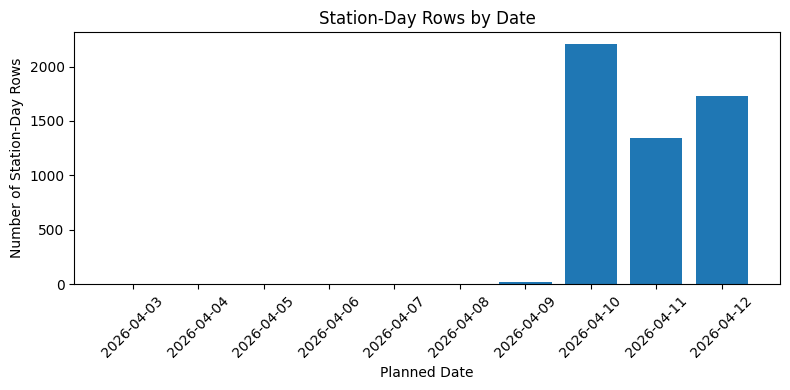

In [66]:
print("Date range:")
print(station_day_df["planned_date"].min(), "to", station_day_df["planned_date"].max())

daily_rows = (
    station_day_df
    .groupby("planned_date")
    .size()
    .reset_index(name="station_day_rows")
)

display(daily_rows)

plt.figure(figsize=(8, 4))
plt.bar(daily_rows["planned_date"], daily_rows["station_day_rows"])
plt.title("Station-Day Rows by Date")
plt.xlabel("Planned Date")
plt.ylabel("Number of Station-Day Rows")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [67]:
print("=" * 70)
print("DATASET SUMMARY")
print("=" * 70)
print(f"Total rows:             {len(station_day_df):,}")
print(f"Unique stations:        {station_day_df['station_name'].nunique():,}")
print(f"Date range (planned):   {station_day_df['planned_date'].min()} - {station_day_df['planned_date'].max()}")
print()

DATASET SUMMARY
Total rows:             5,300
Unique stations:        2,299
Date range (planned):   2026-04-03 00:00:00 - 2026-04-12 00:00:00



In [68]:
station_day_df["train_movements"].describe()

count    5300.000000
mean        5.515094
std         6.934626
min         1.000000
25%         2.000000
50%         3.000000
75%         7.000000
max       122.000000
Name: train_movements, dtype: float64

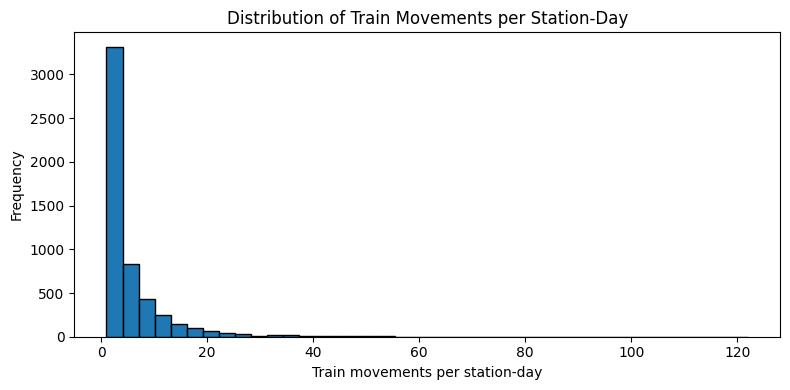

In [69]:
plt.figure(figsize=(8, 4))
plt.hist(station_day_df["train_movements"], bins=40, edgecolor="black")
plt.title("Distribution of Train Movements per Station-Day")
plt.xlabel("Train movements per station-day")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

## 3. Delay (Target Variable) Distribution

In [70]:
delay = station_day_df["mean_delay_minutes"]
print("Delay statistics (minutes):")
print(delay.describe().round(3))
print(f"\nSkewness: {delay.skew():.4f}")
print(f"Kurtosis: {delay.kurtosis():.4f}")
print()
print("Quantiles:")
print(delay.quantile([0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).round(2))

Delay statistics (minutes):
count    5300.000
mean        0.701
std         4.535
min       -47.500
25%        -0.500
50%         0.125
75%         1.200
max        77.500
Name: mean_delay_minutes, dtype: float64

Skewness: 4.3860
Kurtosis: 77.0248

Quantiles:
0.01    -9.67
0.05    -1.80
0.25    -0.50
0.50     0.12
0.75     1.20
0.95     5.51
0.99    13.51
Name: mean_delay_minutes, dtype: float64


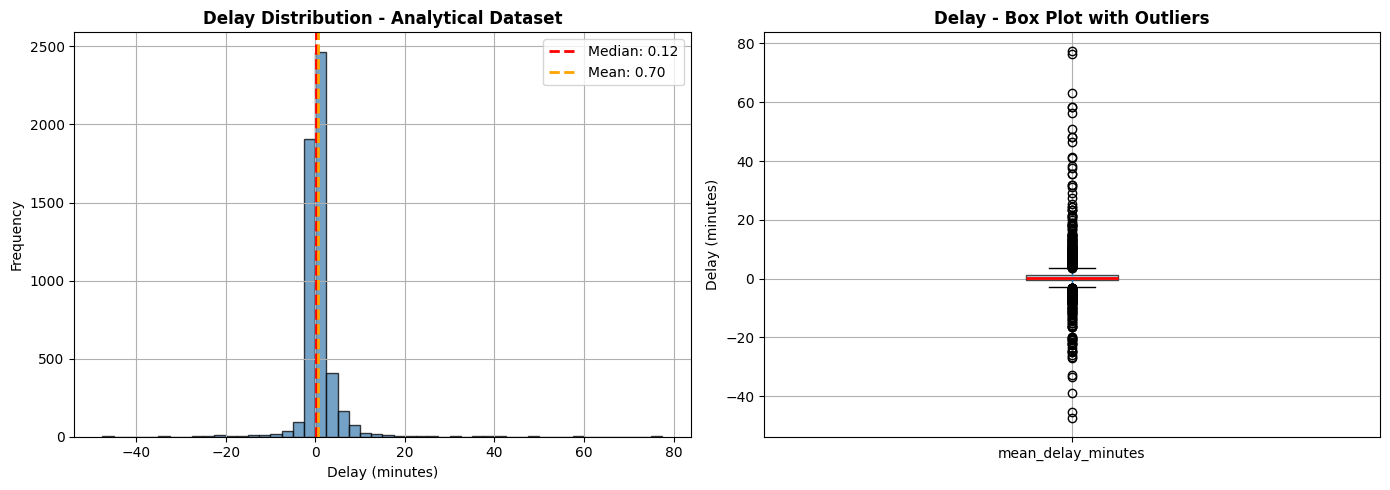

In [71]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

delay.hist(bins=50, ax=axes[0], edgecolor="black", alpha=0.75, color="steelblue")
axes[0].axvline(delay.median(), color="red", linestyle="--", lw=2,
                label=f"Median: {delay.median():.2f}")
axes[0].axvline(delay.mean(), color="orange", linestyle="--", lw=2,
                label=f"Mean: {delay.mean():.2f}")
axes[0].set_xlabel("Delay (minutes)")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Delay Distribution - Analytical Dataset", fontweight="bold")
axes[0].legend()

station_day_df.boxplot(column="mean_delay_minutes", vert=True, ax=axes[1], patch_artist=True,
                    boxprops=dict(facecolor="lightblue", alpha=0.7),
                    medianprops=dict(color="red", linewidth=2))
axes[1].set_ylabel("Delay (minutes)")
axes[1].set_title("Delay - Box Plot with Outliers", fontweight="bold")

plt.tight_layout()
plt.savefig("figures/eda_05_01/delay_distribution.png", dpi=200, bbox_inches="tight")
plt.show()

In [72]:
# Outlier investigation
extreme_early = station_day_df[station_day_df["mean_delay_minutes"] < -30]
extreme_late  = station_day_df[station_day_df["mean_delay_minutes"] > 30]
print(f"Extreme early (< -30 min): {len(extreme_early):,} ({len(extreme_early)/len(station_day_df)*100:.2f}%)")
print(f"Extreme late  (> 30 min):  {len(extreme_late):,} ({len(extreme_late)/len(station_day_df)*100:.2f}%)")
if len(extreme_late):
    print("\nSample extreme late records:")
    display(extreme_late[["station_name","train_movements","planned_date","mean_delay_minutes"]].head(10))

Extreme early (< -30 min): 5 (0.09%)
Extreme late  (> 30 min):  19 (0.36%)

Sample extreme late records:


,station_name,train_movements,planned_date,mean_delay_minutes
124,Andover,1,2026-04-11,35.50
167,Armathwaite,2,2026-04-10,35.75
823,Bury St Edmunds,2,2026-04-12,77.50
1055,Chessington South,1,2026-04-09,63.00
1120,Clandon,1,2026-04-09,48.00
1125,Clapham Junction,5,2026-04-09,56.20
1398,Dean (Wilts),2,2026-04-11,58.50
1648,Effingham Junction,1,2026-04-09,32.00
1693,Epsom,1,2026-04-09,32.00
2695,Kingston,2,2026-04-09,50.75


## 4. Predictor Distributions

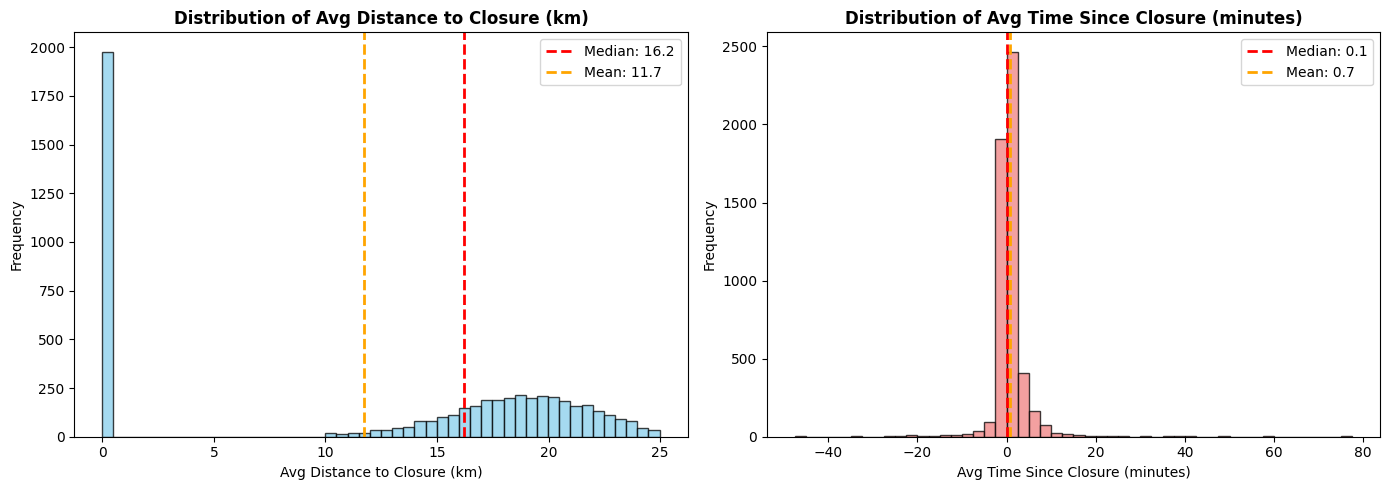

In [73]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, col, color, label in [
    (axes[0], "mean_distance_km", "skyblue", "Avg Distance to Closure (km)"),
    (axes[1], "mean_delay_minutes", "lightcoral", "Avg Time Since Closure (minutes)")
]:
    s = station_day_df[col]
    ax.hist(s, bins=50, edgecolor="black", alpha=0.75, color=color)
    ax.axvline(s.median(), color="red", linestyle="--", lw=2, label=f"Median: {s.median():.1f}")
    ax.axvline(s.mean(), color="orange", linestyle="--", lw=2, label=f"Mean: {s.mean():.1f}")
    ax.set_xlabel(label)
    ax.set_ylabel("Frequency")
    ax.set_title(f"Distribution of {label}", fontweight="bold")
    ax.legend()
plt.tight_layout()
plt.savefig("figures/eda_05_01/predictor_distributions.png", dpi=200, bbox_inches="tight")
plt.show()

## 5. Categorical Distributions

## 6. Bivariate Relationships

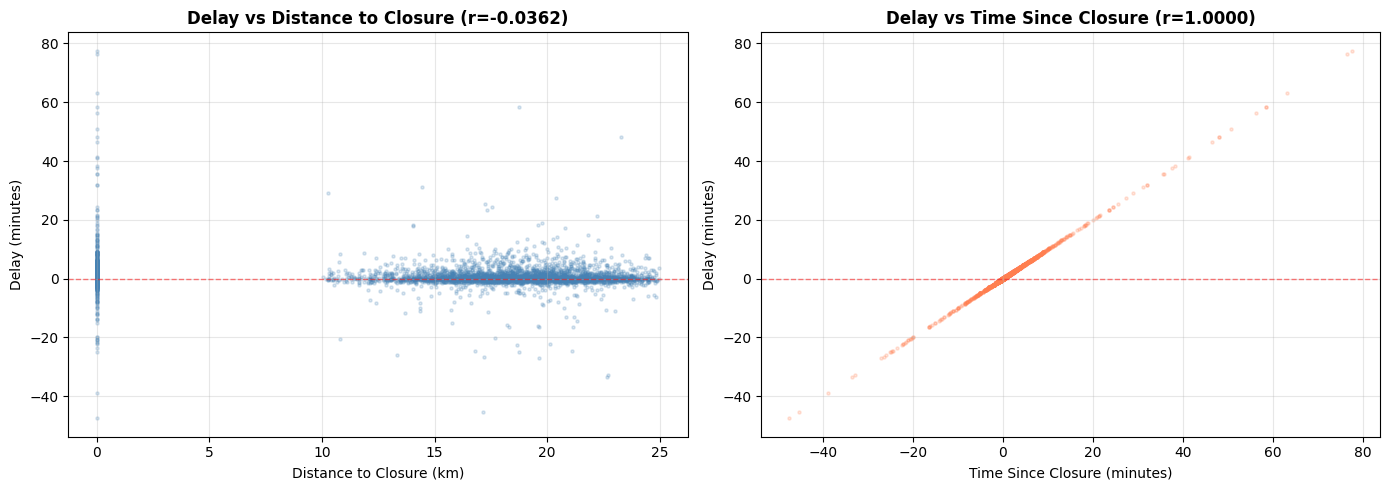

In [74]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, col, color, xlabel in [
    (axes[0], "mean_distance_km", "steelblue", "Distance to Closure (km)"),
    (axes[1], "mean_delay_minutes", "coral", "Time Since Closure (minutes)")
]:
    ax.scatter(station_day_df[col], station_day_df["mean_delay_minutes"],
               alpha=0.2, s=5, color=color)
    ax.axhline(0, color="red", linestyle="--", lw=1, alpha=0.5)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Delay (minutes)")
    corr = station_day_df[[col,"mean_delay_minutes"]].corr().iloc[0,1]
    ax.set_title(f"Delay vs {xlabel.split('(')[0].strip()} (r={corr:.4f})", fontweight="bold")
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("figures/eda_05_01/scatter_delay_vs_predictors.png", dpi=200, bbox_inches="tight")
plt.show()

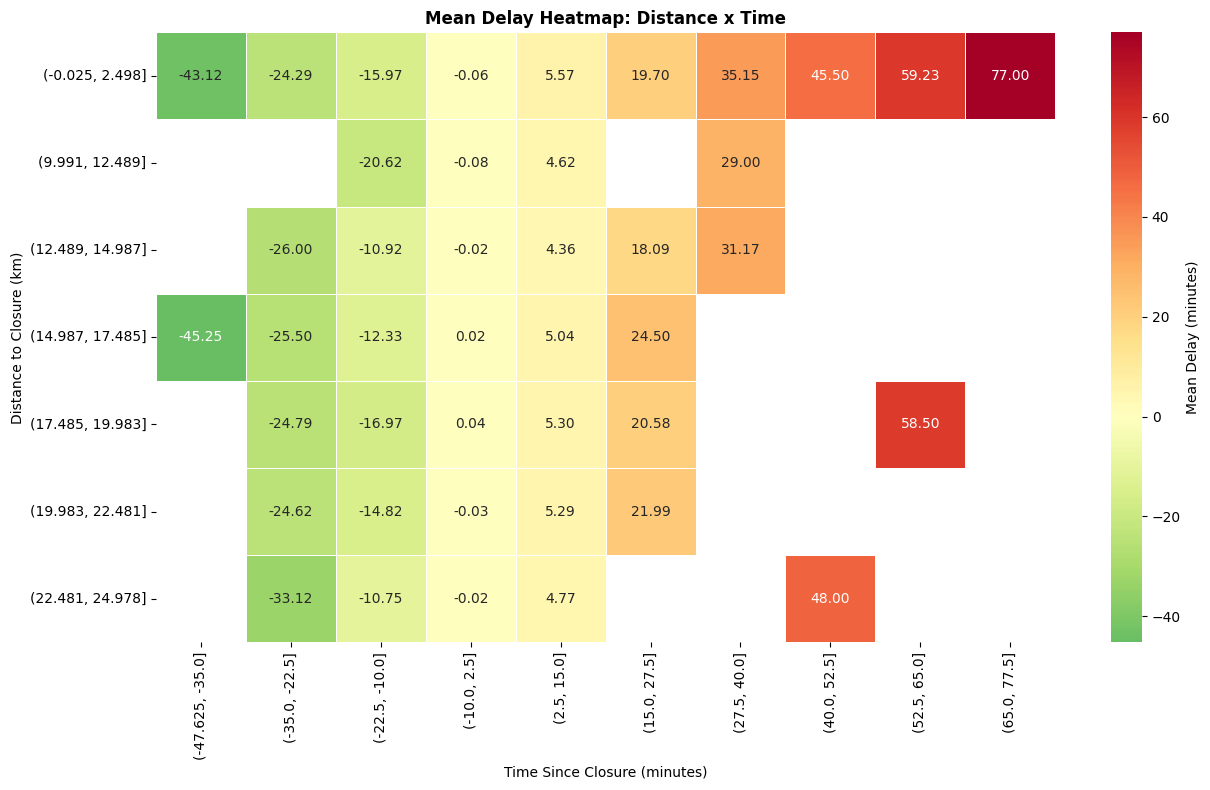

In [75]:
# Distance x time heatmap
hm = station_day_df.copy()
hm["dist_bin"] = pd.cut(hm["mean_distance_km"], bins=10)
hm["time_bin"] = pd.cut(hm["mean_delay_minutes"], bins=10)
pivot = hm.pivot_table(values="mean_delay_minutes", index="dist_bin", columns="time_bin", aggfunc="mean")

plt.figure(figsize=(13, 8))
sns.heatmap(pivot, annot=True, fmt=".2f", cmap="RdYlGn_r", center=0,
            cbar_kws={"label": "Mean Delay (minutes)"}, linewidths=0.5)
plt.xlabel("Time Since Closure (minutes)")
plt.ylabel("Distance to Closure (km)")
plt.title("Mean Delay Heatmap: Distance x Time", fontweight="bold")
plt.tight_layout()
plt.savefig("figures/eda_05_01/heatmap_distance_time.png", dpi=200, bbox_inches="tight")
plt.show()

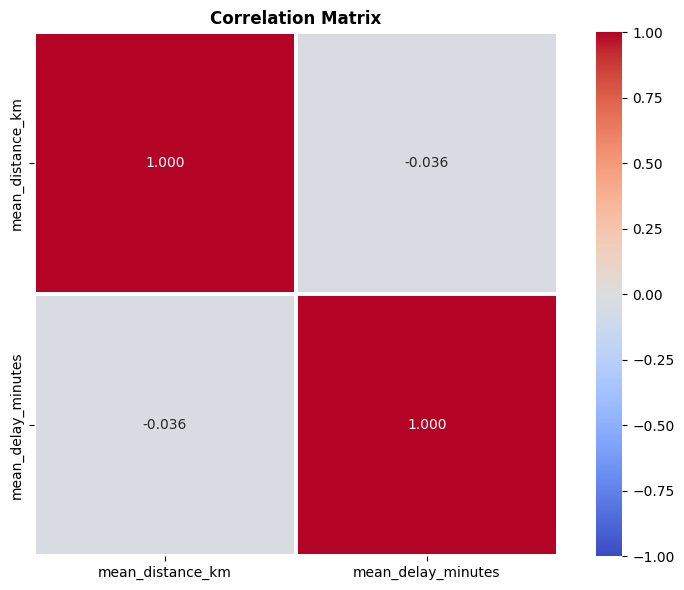


Correlation with delay:
mean_distance_km   -0.036197
Name: mean_delay_minutes, dtype: float64


In [76]:
# Correlation matrix
numeric_cols = ["mean_distance_km", "mean_delay_minutes"]
corr_matrix = station_day_df[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".3f", cmap="coolwarm", center=0,
            square=True, linewidths=1.5, vmin=-1, vmax=1)
plt.title("Correlation Matrix", fontweight="bold")
plt.tight_layout()
plt.savefig("figures/eda_05_01/correlation_matrix.png", dpi=200, bbox_inches="tight")
plt.show()
print("\nCorrelation with delay:")
print(corr_matrix["mean_delay_minutes"].drop("mean_delay_minutes").sort_values())

## 7. Temporal Patterns

## 8. Spatial Patterns

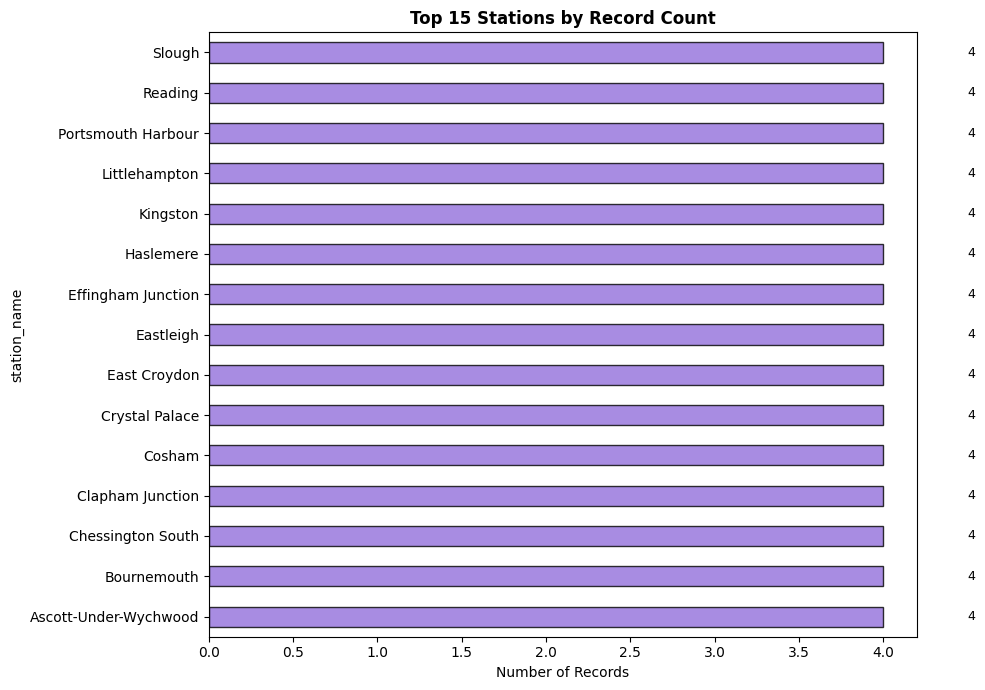

Top 15 stations: 60 rows (1.1% of total)


In [77]:
top_stations = station_day_df["station_name"].value_counts().head(15)
plt.figure(figsize=(10, 7))
top_stations.plot(kind="barh", color="mediumpurple", edgecolor="black", alpha=0.8)
plt.xlabel("Number of Records")
plt.title("Top 15 Stations by Record Count", fontweight="bold")
for i, v in enumerate(top_stations.values):
    plt.text(v + 0.5, i, str(v), va="center", fontsize=9)
plt.tight_layout()
plt.savefig("figures/eda_05_01/top_stations.png", dpi=200, bbox_inches="tight")
plt.show()
print(f"Top 15 stations: {top_stations.sum():,} rows ({top_stations.sum()/len(station_day_df)*100:.1f}% of total)")

## 9. Save Analytical Dataset

In [78]:
station_day_df.to_parquet("./data/processed/road_station_day_dataset.parquet", index=False)
print(f"Saved road_station_day dataset: {len(station_day_df):,} rows")
print("Path: data/processed/road_station_day_dataset.parquet")
print()
print("Column summary:")
station_day_df.info()

Saved road_station_day dataset: 5,300 rows
Path: data/processed/road_station_day_dataset.parquet

Column summary:
<class 'pandas.DataFrame'>
RangeIndex: 5300 entries, 0 to 5299
Data columns (total 30 columns):
 #   Column                         Non-Null Count  Dtype        
---  ------                         --------------  -----        
 0   station_name                   5300 non-null   str          
 1   stanox                         5300 non-null   str          
 2   planned_date                   5300 non-null   datetime64[s]
 3   train_movements                5300 non-null   int64        
 4   mean_delay_minutes             5300 non-null   float64      
 5   median_delay_minutes           5300 non-null   float64      
 6   late_movements                 5300 non-null   int64        
 7   mean_late_minutes              5300 non-null   float64      
 8   median_late_minutes            5300 non-null   float64      
 9   max_late_minutes               5300 non-null   float64     